## Exercise 1: Bayesian optimization
1. Define an objective function which returns the analytic expression of a 1d polynomial with coefficients f(x) = 0.05 (x^6 - 2 x^5 - 28 x^4 + 28 x^3 + 12 x^2 -26 x + 100).

2. Plot the previous function using a linear grid of points in x between [-5, 6].

3. Define an uniform search domain space using hyperopt. With hyperopt.pyll.stochastic.sample build an histogram with samples from that space.

4. Perform the objective function minimization using the Tree-structured Parzen Estimator model, 2000 evaluations and store the trials using hyperopt.Trials. Print to screen the best value of x. Show scatter plot with the x-value vs iteration together with the final best value of x. Show the histogram of x-values extracted during the scan.

5. Repeat the previous point now using a random search algorithm.

In [1]:
import hyperopt
from hyperopt import hp, tpe, Trials, fmin, rand
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    p = np.poly1d([1,-2,-28,28,12,-26,100])
    return p(x)*0.05

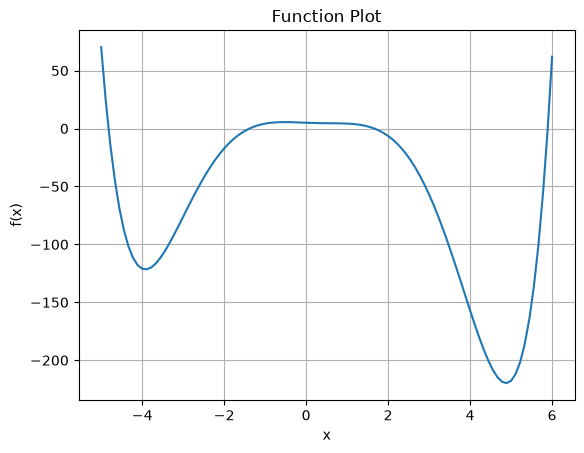

In [8]:
# . Plot the previous function using a linear grid of points in x between [-5, 6].
x_values = np.linspace(-5, 6, 100)
y_values = f(x_values)

plt.plot(x_values, y_values)
plt.title("Function Plot")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()  
plt.show()


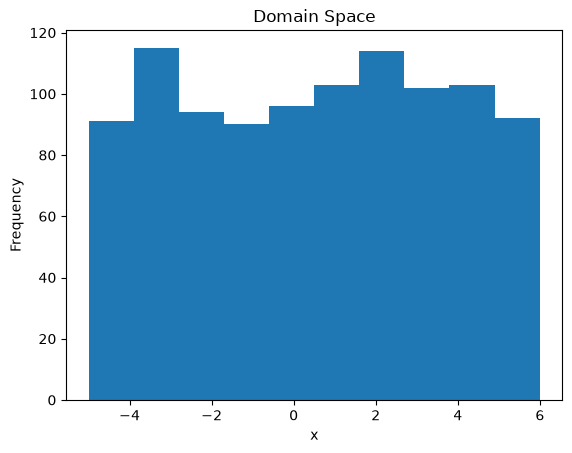

100%|██████████| 2000/2000 [00:05<00:00, 336.51trial/s, best loss: -219.80119214251064]
{'x': np.float64(4.877829657237992)}


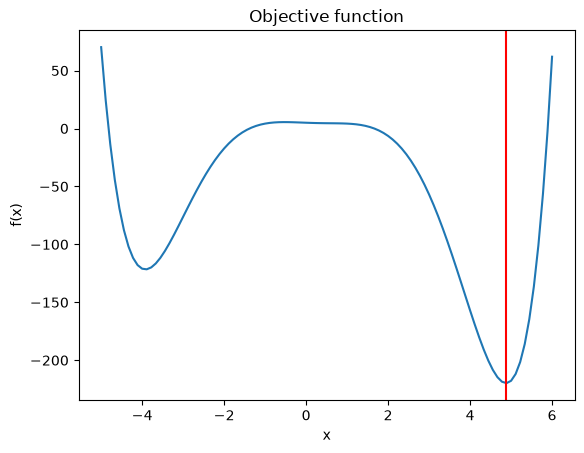

In [4]:
space = hp.uniform('x', -5, 6)
plt.hist([hyperopt.pyll.stochastic.sample(space) for _ in range(1000)])
plt.title("Domain Space")
plt.xlabel("x")
plt.ylabel("Frequency")
plt.show()

# Run 2000 evals with the tpe algorithm
tpe_trials = Trials()
tpe_best = fmin(fn=f, space=space,
                algo=tpe.suggest, trials=tpe_trials,
                max_evals=2000)
print(tpe_best)

# Point 2-3
x = np.linspace(-5, 6, 100)
plt.plot(x, f(x))
plt.axvline(tpe_best['x'], color='red')
plt.title("Objective function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

100%|██████████| 2000/2000 [00:02<00:00, 940.91trial/s, best loss: -219.79834628105277] 
{'x': np.float64(4.873434412306382)}


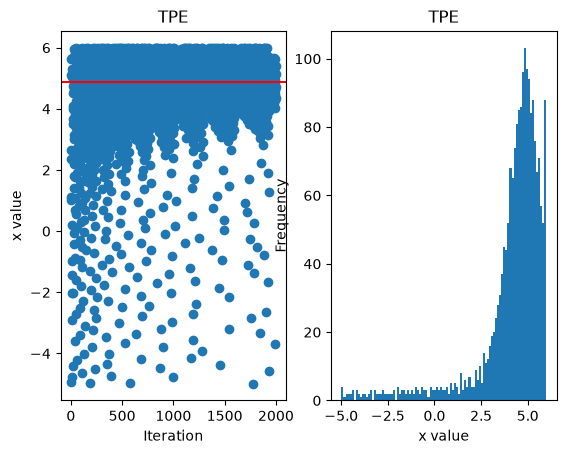

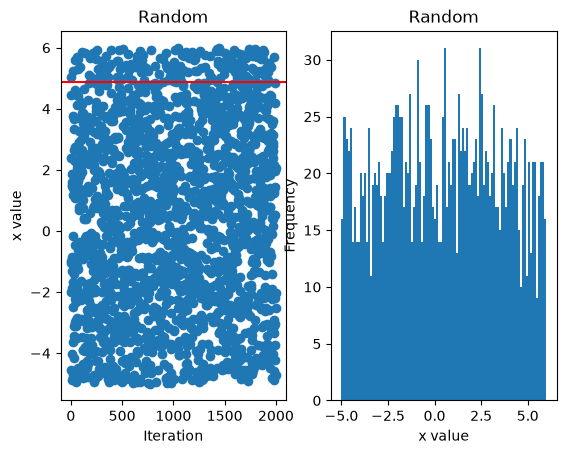

In [9]:
# Point 4
_, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(tpe_trials.idxs_vals[0]['x'], tpe_trials.idxs_vals[1]['x'])
ax1.axhline(tpe_best['x'], color='red')
ax1.set_xlabel("Iteration")
ax1.set_ylabel("x value")
ax1.set_title("TPE")
ax2.hist(tpe_trials.idxs_vals[1]['x'], bins=100)
ax2.set_xlabel("x value")
ax2.set_ylabel("Frequency")
ax2.set_title("TPE")

# Point 5
rdn_trials = Trials()
rdn_best = fmin(fn=f, space=space,
                algo=rand.suggest, trials=rdn_trials,
                max_evals=2000)
print(rdn_best)

_, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(rdn_trials.idxs_vals[0]['x'], rdn_trials.idxs_vals[1]['x'])
ax1.axhline(rdn_best['x'], color='red')
ax1.set_xlabel("Iteration")
ax1.set_ylabel("x value")
ax1.set_title("Random")
ax2.hist(rdn_trials.idxs_vals[1]['x'], bins=100)
ax2.set_xlabel("x value")
ax2.set_ylabel("Frequency")
ax2.set_title("Random")
plt.show()


## Exercise 2: Hyperparameter scan for classifier
Write a DL regression model using Keras with the following steps:

Data loading

Load the mnist dataset from tensorflow.keras.datasets.mnist. Study the dataset size (shape) and normalize the pixels.

DNN model

Design a NN architecture for the classification of all digits.

Hyperparameter scan

Define a function which parametrizes the learning rate and the number of units of the DNN model using a python dict.

Use the Tree-structured Parzen Estimator with the hyperopt library.

Plot the accuracy vs learning rate and number of layers for each trial.

In [12]:
# Import delle librerie: TensorFlow/Keras per costruire e allenare la rete neurale,
# hyperopt per la ricerca bayesiana degli iperparametri (TPE)
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from hyperopt import fmin, tpe, hp, Trials, space_eval, STATUS_OK
import matplotlib.pyplot as plt
import numpy as np

### Teoria: Data loading

Il dataset **MNIST** contiene 70000 immagini in scala di grigi (28x28 pixel) di cifre scritte a mano (0-9), gia' divise in training set (60000 immagini) e test set (10000 immagini). Ogni pixel ha un valore intero tra 0 e 255.

Prima di darle in pasto alla rete conviene **normalizzare** i pixel portandoli nell'intervallo [0, 1] (dividendo per 255): input piu' piccoli e omogenei rendono l'addestramento piu' stabile e veloce, perche' i gradienti calcolati durante il training restano su scale ragionevoli.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
train: (60000, 28, 28)
test: (10000, 28, 28)


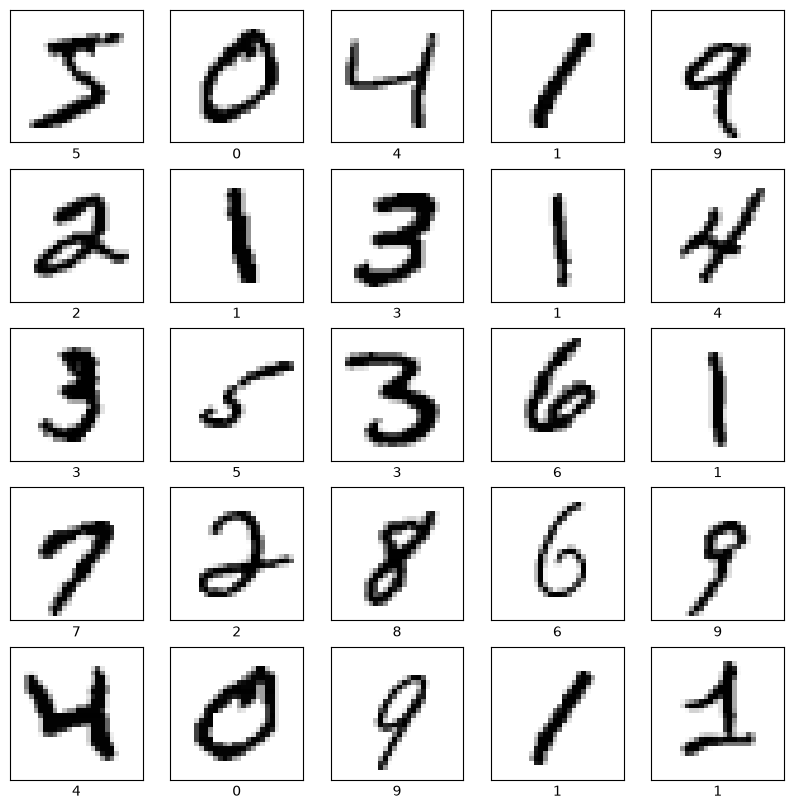

In [13]:
# Punto 1: Data loading
# Carichiamo il dataset MNIST, gia' diviso in training set e test set
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalizziamo i pixel: da [0, 255] a [0, 1]
train_images = train_images / 255
test_images = test_images / 255

# Controlliamo la dimensione (shape) dei due set
print('train:', train_images.shape)
print('test:', test_images.shape)

# Funzione di supporto per visualizzare alcune immagini di esempio con la relativa etichetta
def plot_sample(images, labels):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(labels[i])
    plt.show()

plot_sample(train_images, train_labels)

### Teoria: DNN model

L'architettura scelta e' una rete **fully-connected** (MLP) molto semplice:

- **Flatten**: trasforma ogni immagine 28x28 in un vettore di 784 valori, perche' i layer `Dense` si aspettano un input 1D.
- **Dense(hidden, relu)**: layer nascosto con attivazione **ReLU**, che introduce non-linearita' e permette alla rete di imparare pattern complessi.
- **Dense(10, softmax)**: layer di output con 10 neuroni (uno per cifra) e attivazione **softmax**, che trasforma gli output in una distribuzione di probabilita' sulle 10 classi.

Come loss usiamo `sparse_categorical_crossentropy` (adatta quando le etichette sono interi e non one-hot) e come metrica l'`accuracy`.

Definiamo due funzioni riutilizzabili — `train` (costruisce, allena e restituisce il modello) e `test` (calcola loss/accuracy sul test set) — che verranno riusate anche nello scan degli iperparametri. Prima pero' costruiamo e alleniamo "a mano" un primo modello di riferimento, per verificare che l'architettura funzioni.

In [14]:
# Punto 2: DNN model
# Funzione che costruisce e allena il modello, parametrizzata su numero di unita' e learning rate
def train(features, labels, parameters):
    model = Sequential()
    model.add(Flatten(input_shape=(28,28)))                                   # 28x28 -> vettore di 784 valori
    model.add(Dense(units=int(parameters['layer_size']), activation='relu'))  # hidden layer, dimensione parametrizzabile
    model.add(Dense(10, activation='softmax'))                                # output: probabilita' sulle 10 cifre

    adam = Adam(learning_rate=parameters['learning_rate'])
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=adam, metrics=['accuracy'])
    model.fit(features, labels, epochs=5)
    return model

# Funzione che valuta il modello sul test set
def test(model, features, labels):
    acc = model.evaluate(features, labels)
    return acc

# Modello di riferimento costruito "a mano" (2 unita' nel hidden layer) per verificare che l'architettura funzioni
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(2, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5)
test_acc = test(model, test_images, test_labels)
print(f'Test accuracy {test_acc}')

# Verifichiamo anche la funzione train() con una configurazione di parametri fissata
test_setup = {
    'layer_size': 2,
    'learning_rate': 1.0
}
model = train(train_images, train_labels, test_setup)
print('Accuracy on test set is:', test(model, test_images, test_labels)[1])

/home/alice/anaconda3/envs/DL_first_project/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         1,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,600 (6.25 KB)

 Trainable params: 1,600 (6.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3804 - loss: 1.6827
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5371 - loss: 1.2727
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5577 - loss: 1.1347
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5626 - loss: 1.0907
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5774 - loss: 1.0663
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5950 - loss: 1.0593
Test accuracy [1.0592576265335083, 0.5950000286102295]
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1015 - loss: 2.5178
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1037 - loss: 2.4093
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0987 - loss: 2.4062
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0995 - loss: 2.4090
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1020 - loss: 2.4113


### Teoria: hyperparameter scan con TPE

Vogliamo trovare la combinazione di `learning_rate` e numero di unita' del hidden layer (`layer_size`) che massimizza l'accuracy sul test set, usando **hyperopt** con l'algoritmo **Tree-structured Parzen Estimator (TPE)** (lo stesso usato nell'Esercizio 1).

- **Funzione obiettivo** (`hyper_func`): allena un modello con i parametri proposti da hyperopt e restituisce un dizionario con `loss` e `status`. Siccome `fmin` **minimizza** la loss, mentre a noi interessa **massimizzare** l'accuracy, restituiamo `-accuracy` come loss.
- **Spazio di ricerca** (`search_space`):
  - `layer_size`: scelto tra valori discreti con `hp.choice` (10, 30, 50, 70, 90).
  - `learning_rate`: campionato con `hp.loguniform`, adatto quando il parametro varia su piu' ordini di grandezza (qui tra e^-10 ed e^0).
- **Trials**: oggetto che tiene traccia di tutte le prove effettuate durante la ricerca, cosi' da poterle analizzare e plottare in seguito.

In [15]:
# Punto 3: Hyperparameter scan
def hyper_func(params):
    model = train(train_images, train_labels, params)
    test_acc = test(model, test_images, test_labels)
    return {'loss': -test_acc[1], 'status': STATUS_OK}  # -accuracy: fmin minimizza, noi vogliamo massimizzare l'accuracy

search_space = {
    'layer_size': hp.choice('layer_size', np.arange(10, 100, 20)),
    'learning_rate': hp.loguniform('learning_rate', -10, 0)
}

trials = Trials()
best = fmin(hyper_func, search_space, algo=tpe.suggest, max_evals=5, trials=trials)
print(space_eval(search_space, best))

Epoch 1/5                                            

   1/1875 ━━━━━━━━━━━━━━━━━━━━ 31:09 997ms/step - accuracy: 0.0312 - loss: 2.4655
  12/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3776 - loss: 1.7166     
  25/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5663 - loss: 1.2788
  38/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6562 - loss: 1.0489
  52/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7079 - loss: 0.8898
  65/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7312 - loss: 0.8207
  78/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7544 - loss: 0.7562
  93/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7752 - loss: 0.6975
 108/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7908 - loss: 0.6462
 125/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8033 - loss: 0.6175
 142/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8112 - loss: 0.5984
 157/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8165 - loss: 0.5817
 171/1875 ━

### Teoria: visualizzazione dei risultati

Per ogni prova (`trial`) salvata in `trials`, plottiamo l'accuracy ottenuta rispetto a tre grandezze diverse, per capire come i due iperparametri influenzano la performance:

1. **Iterazione** (`tid`): l'accuracy tende a migliorare (o restare stabile) man mano che TPE affina la ricerca sfruttando le prove precedenti.
2. **layer_size**: mostra se un hidden layer piu' grande aiuta la classificazione.
3. **learning_rate**: mostra la sensibilita' del modello al learning rate — spesso esiste un valore "ottimale", ne' troppo piccolo (convergenza lenta) ne' troppo grande (instabilita').

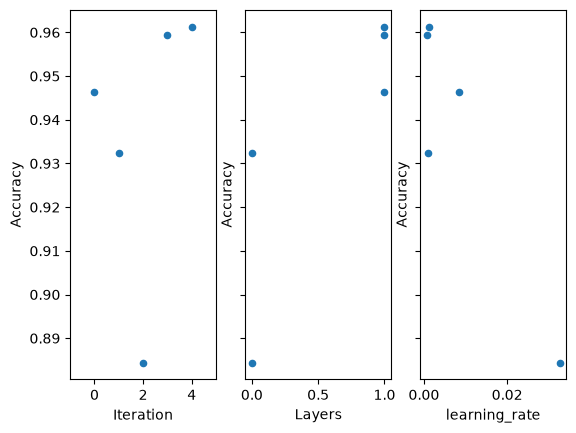

In [16]:
# Punto 3: Plot dell'accuracy rispetto a iterazione, layer_size e learning_rate per ogni trial
_, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True)

xs = [t['tid'] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax1.set_xlim(xs[0]-1, xs[-1]+1)
ax1.scatter(xs, ys, s=20)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Accuracy')

xs = [t['misc']['vals']['layer_size'] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax2.scatter(xs, ys, s=20)
ax2.set_xlabel('Layers')
ax2.set_ylabel('Accuracy')

xs = [t['misc']['vals']['learning_rate'] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax3.scatter(xs, ys, s=20)
ax3.set_xlabel('learning_rate')
ax3.set_ylabel('Accuracy')
plt.show()